# Exploratory Data Analysis for EMG (Electrocardiogram) signal

Type: Muscle activity sensor\
Unit: mV

EMG measures muscle tension.

**Why EMG helps detect stress**

When stressed:
- muscles tighten
- jaw / shoulders tense
- small muscle activations increase

Example:
| State  | Muscle activity |
| ------ | --------------- |
| Calm   | low EMG         |
| Stress | high EMG        |

> negative values in EMG are completely normal and expected.

Muscle electrical activity behaves like a wave signal.

When a muscle fiber activates, it creates action potentials that move across the muscle. Because electrodes measure voltage difference, the signal can go:
- positive
- negative
- positive again

Example raw EMG signal:
```
time → 

0.004
0.002
-0.003
-0.005
0.001
0.006
```
Raw EMG values are not used directly in most models.

Researchers usually transform them first i.e, Convert negatives to positive values.
```
EMG_raw = [-0.004, 0.003, -0.002]

EMG_rectified = [0.004, 0.003, 0.002]
```

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv("../../Dataset/S2_chest_data.csv")
accept_label = [1, 2, 3, 4]
df = df[df["Label"].isin(accept_label)]

nStr = [1, 3, 4]
def apply_target(label):
    if label == 2:
        return "stressed"
    elif label in nStr:
        return "not stressed"
    else:
        return "unknown"

df["target"] = df["Label"].apply(apply_target)

df.head(2)

,ACC_X,ACC_Y,ACC_Z,ECG,EMG,EDA,Temp,Resp,Label,target
214583,0.8914,-0.1102,-0.2576,0.030945,-0.003708,5.710983,29.083618,1.191711,1,not stressed
214584,0.8926,-0.1086,-0.2544,0.033646,-0.014145,5.719376,29.122437,1.139832,1,not stressed


## EDA Starts here

Since:

Raw EMG values are not used directly in most models.

Researchers usually transform them first i.e, Convert negatives to positive values.
```
EMG_raw = [-0.004, 0.003, -0.002]

EMG_rectified = [0.004, 0.003, 0.002]

In [25]:
df["EMG"] = df["EMG"].abs()

In [8]:
df["EMG"].describe()

count    2.022299e+06
mean     7.232439e-03
std      6.878839e-03
min      0.000000e+00
25%      2.426147e-03
50%      5.355835e-03
75%      9.933472e-03
max      2.458191e-01
Name: EMG, dtype: float64

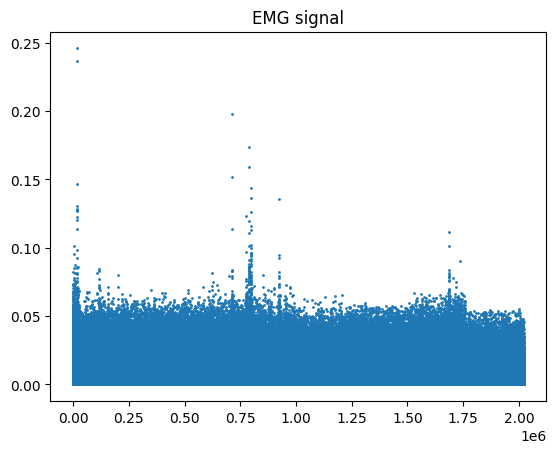

In [26]:
plt.scatter(range(len(df)), df["EMG"], s=1)
plt.title("EMG signal")
plt.show()

In [27]:
str_EDA = df[df["target"] == "stressed"]
nStr_EDA = df[df["target"] == "not stressed"]

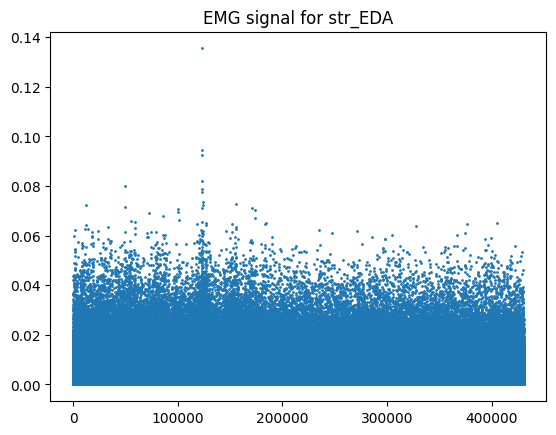

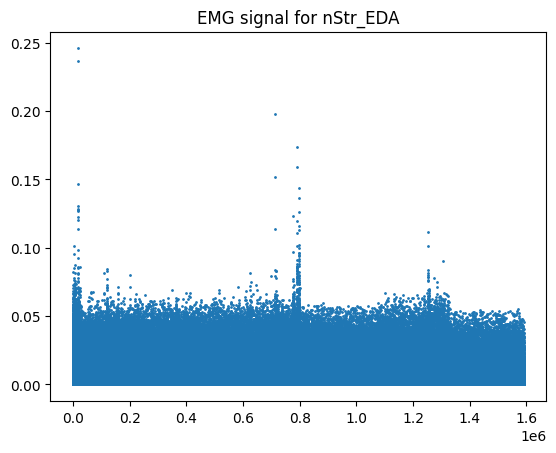

In [28]:
plt.scatter(range(len(str_EDA)), str_EDA["EMG"], s=1)
plt.title("EMG signal for str_EDA")
plt.show()

plt.scatter(range(len(nStr_EDA)), nStr_EDA["EMG"], s=1)
plt.title("EMG signal for nStr_EDA")
plt.show()

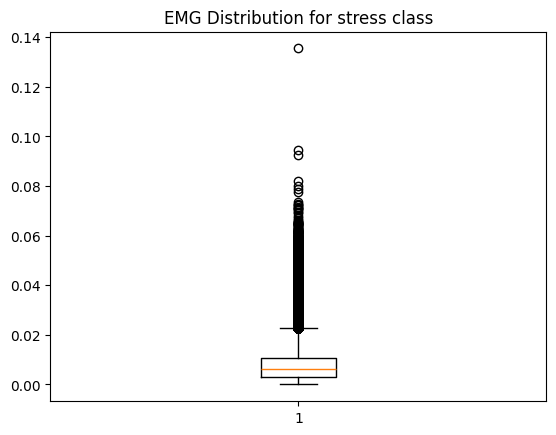

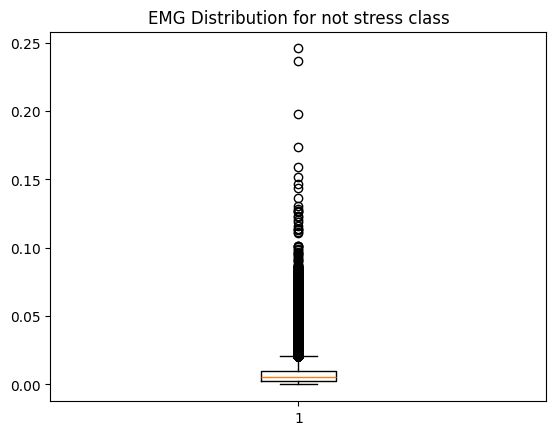

In [29]:
plt.boxplot(str_EDA["EMG"])
plt.title("EMG Distribution for stress class")
plt.show()

plt.boxplot(nStr_EDA["EMG"])
plt.title("EMG Distribution for not stress class")
plt.show()

### Removing the outlier of stress class

C:\Users\Yadnesh\AppData\Local\Temp\ipykernel_31576\385446084.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  new_df = str_EDA[(df["EMG"] >= lower) & (str_EDA["EMG"] <= upper)]
C:\Users\Yadnesh\AppData\Local\Temp\ipykernel_31576\385446084.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  new_df = str_EDA[(df["EMG"] >= lower) & (str_EDA["EMG"] <= upper)]
C:\Users\Yadnesh\AppData\Local\Temp\ipykernel_31576\385446084.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  new_df = str_EDA[(df["EMG"] >= lower) & (str_EDA["EMG"] <= upper)]
C:\Users\Yadnesh\AppData\Local\Temp\ipykernel_31576\385446084.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  new_df = str_EDA[(df["EMG"] >= lower) & (str_EDA["EMG"] <= upper)]


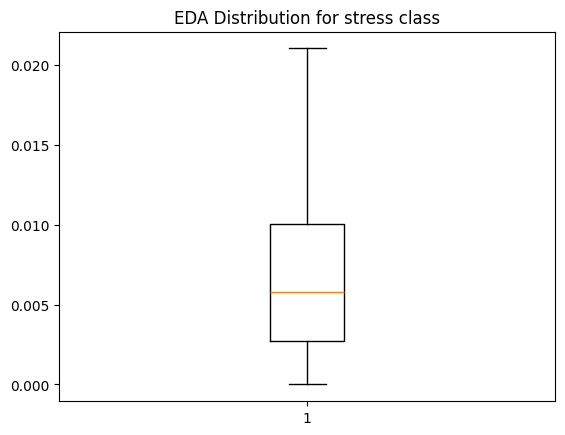

In [30]:
while True:
    Q1 = str_EDA["EMG"].quantile(0.25)
    Q3 = str_EDA["EMG"].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    new_df = str_EDA[(df["EMG"] >= lower) & (str_EDA["EMG"] <= upper)]

    # stop when no more rows are removed
    if len(new_df) == len(str_EDA):
        break

    str_EDA = new_df

plt.boxplot(str_EDA["EMG"])
plt.title("EDA Distribution for stress class")
plt.show()

### Removing the outlier of non stress class

C:\Users\Yadnesh\AppData\Local\Temp\ipykernel_31576\3123256773.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  new_df = nStr_EDA[(df["EMG"] >= lower) & (nStr_EDA["EMG"] <= upper)]
C:\Users\Yadnesh\AppData\Local\Temp\ipykernel_31576\3123256773.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  new_df = nStr_EDA[(df["EMG"] >= lower) & (nStr_EDA["EMG"] <= upper)]
C:\Users\Yadnesh\AppData\Local\Temp\ipykernel_31576\3123256773.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  new_df = nStr_EDA[(df["EMG"] >= lower) & (nStr_EDA["EMG"] <= upper)]
C:\Users\Yadnesh\AppData\Local\Temp\ipykernel_31576\3123256773.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  new_df = nStr_EDA[(df["EMG"] >= lower) & (nStr_EDA["EMG"] <= upper)]
C:\Users\Yadnesh\AppData\Local\Temp\ipykernel_31576\3123256773.py:10: UserWarning: Boolean Series key will be reindexed to match Dat

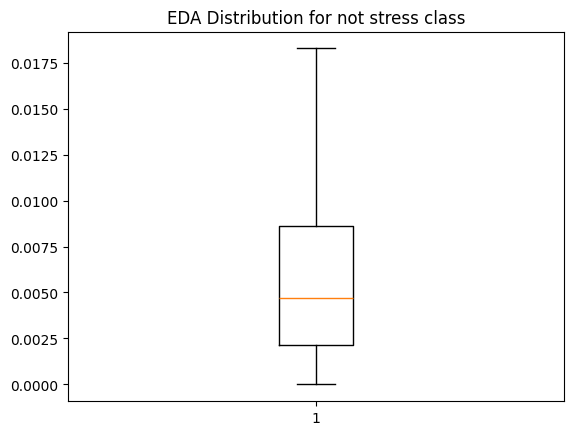

In [31]:
while True:
    Q1 = nStr_EDA["EMG"].quantile(0.25)
    Q3 = nStr_EDA["EMG"].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    new_df = nStr_EDA[(df["EMG"] >= lower) & (nStr_EDA["EMG"] <= upper)]

    # stop when no more rows are removed
    if len(new_df) == len(nStr_EDA):
        break

    nStr_EDA = new_df

plt.boxplot(nStr_EDA["EMG"])
plt.title("EDA Distribution for not stress class")
plt.show()

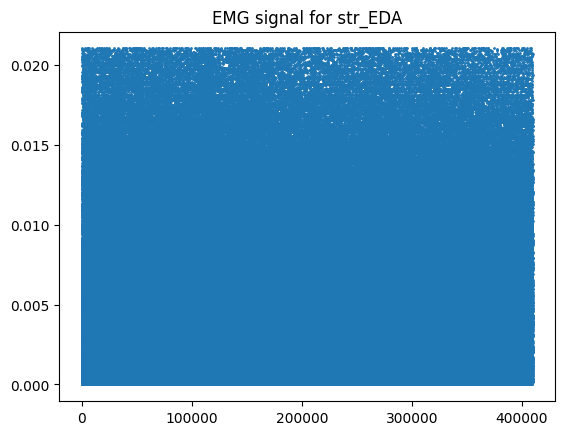

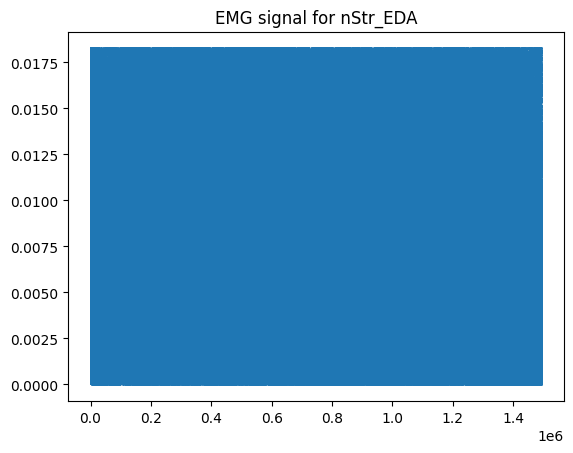

In [32]:
plt.scatter(range(len(str_EDA)), str_EDA["EMG"], s=1)
plt.title("EMG signal for str_EDA")
plt.show()

plt.scatter(range(len(nStr_EDA)), nStr_EDA["EMG"], s=1)
plt.title("EMG signal for nStr_EDA")
plt.show()

This might not be the proper way to remove the outlier as we are loosing too much data

In [61]:
str_EDA = df[df["target"] == "stressed"]
nStr_EDA = df[df["target"] == "not stressed"]

In [49]:
str_EDA = str_EDA[str_EDA["EMG"] < 0.08]
nStr_EDA = nStr_EDA[nStr_EDA["EMG"]< 0.08]

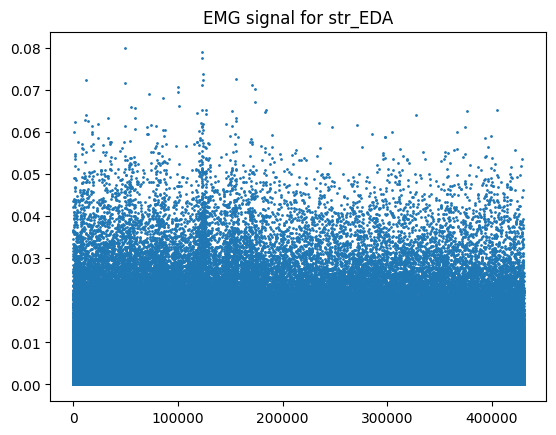

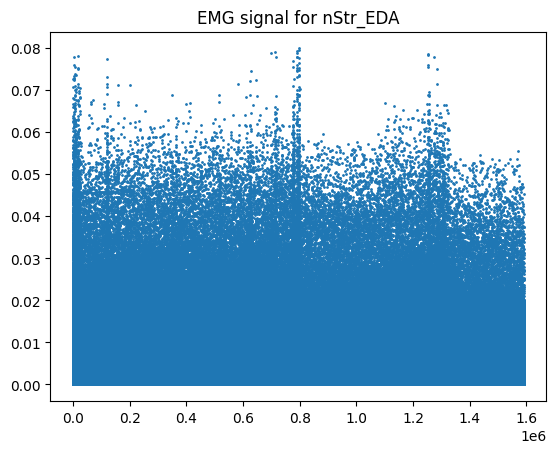

In [50]:
plt.scatter(range(len(str_EDA)), str_EDA["EMG"], s=1)
plt.title("EMG signal for str_EDA")
plt.show()

plt.scatter(range(len(nStr_EDA)), nStr_EDA["EMG"], s=1)
plt.title("EMG signal for nStr_EDA")
plt.show()

Although
| State  | Muscle activity |
| ------ | --------------- |
| Calm   | low EMG         |
| Stress | high EMG        |

we are not seeing the relation in this graph, this might be because of imbalance dataset

In [62]:
print(len(str_EDA))
print(len(nStr_EDA))

430500
1591799


### Balance out the dataset

In [52]:
from sklearn.utils import resample

# majority class
low_stress = nStr_EDA

# minority class
high_stress = str_EDA

low_downsampled = resample(
    low_stress,
    replace=False,
    n_samples=len(high_stress),
    random_state=42
)

balanced = pd.concat([low_downsampled, high_stress]).sample(frac=1)

In [59]:
str_EDA = balanced[df["target"] == "stressed"]
nStr_EDA = balanced[df["target"] == "not stressed"]

C:\Users\Yadnesh\AppData\Local\Temp\ipykernel_31576\2747496669.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  str_EDA = balanced[df["target"] == "stressed"]
C:\Users\Yadnesh\AppData\Local\Temp\ipykernel_31576\2747496669.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  nStr_EDA = balanced[df["target"] == "not stressed"]


In [54]:
print(len(str_EDA))
print(len(nStr_EDA))

430496
430496


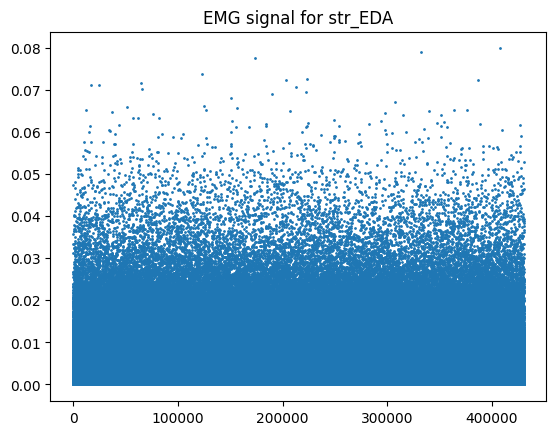

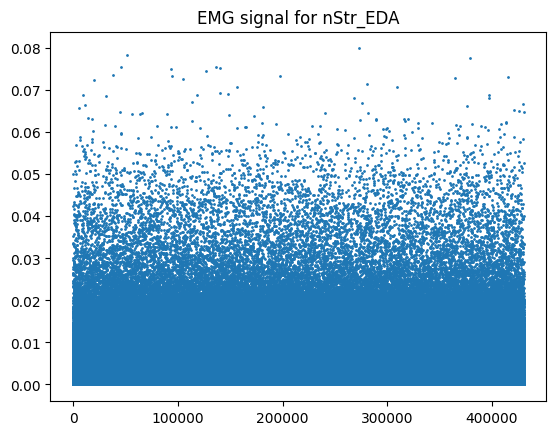

In [55]:
plt.scatter(range(len(str_EDA)), str_EDA["EMG"], s=1)
plt.title("EMG signal for str_EDA")
plt.show()

plt.scatter(range(len(nStr_EDA)), nStr_EDA["EMG"], s=1)
plt.title("EMG signal for nStr_EDA")
plt.show()

In [57]:
str_EDA["EMG"].describe()

count    430496.000000
mean          0.007847
std           0.006879
min           0.000000
25%           0.002838
50%           0.006088
75%           0.010849
max           0.079834
Name: EMG, dtype: float64

In [58]:
nStr_EDA["EMG"].describe()

count    430496.000000
mean          0.007059
std           0.006836
min           0.000000
25%           0.002335
50%           0.005173
75%           0.009659
max           0.079926
Name: EMG, dtype: float64

Now we can see proper relation

| State  | Muscle activity |
| ------ | --------------- |
| Calm   | low EMG         |
| Stress | high EMG        |